# Notebook 02: Outlier cleaning

Loads the EDA output, applies selected outlier cleaning, and writes intermediate data.

## 1. Notebook set-up

In [1]:
import contextlib
import io
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy.stats import f_oneway, ttest_rel
from statsmodels.stats.multitest import multipletests
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

sys.path.insert(0, str(Path.cwd().resolve().parent / 'src'))
import featurely as fl

from config import DATA_DIR, OUTLIER_METHOD, OUTLIER_THRESHOLD

## 2. Data loading

In [2]:
in_path = DATA_DIR / '01-EDA.csv'

if not in_path.exists():
    raise FileNotFoundError(
        (f'Missing required input file: {in_path}. Run 01-EDA.ipynb ' +
         'first to generate data/01-EDA.csv.')
    )

housing_df = pd.read_csv(in_path)
features = [c for c in housing_df.columns if c != 'MedHouseVal']
print(f'Loaded: {in_path}')

Loaded: /workspaces/featurely/data/01-EDA.csv


## 3. Method comparison experiment

Before selecting a cleaning strategy, we evaluate all three methods plus no cleaning using the same 10-fold cross-validation setup used at the end of the notebook. A one-way ANOVA then tests whether any differences in mean R² are statistically significant.

Note: CV fold scores from the same dataset are not fully independent, so treat the ANOVA as a practical first-pass comparison rather than a strict hypothesis test.

In [3]:
methods = ['ignore', 'clip', 'impute', 'transform']
cv_results = {}

for method in methods:

    df = housing_df.copy()

    with contextlib.redirect_stdout(io.StringIO()):
        if method == 'clip':
            df = fl.clip_outliers(df, features)

        elif method == 'impute':
            df = fl.impute_outliers_with_knn(df, features, n_neighbors=7)

        elif method == 'transform':
            df = fl.transform_outliers(df, features)

    scores = cross_val_score(
        LinearRegression(),
        df.drop('MedHouseVal', axis=1),
        df['MedHouseVal'],
        cv=10,
        scoring='r2'
    )

    cv_results[method] = scores
    print(f'{method:>10}: mean R2 = {scores.mean():.4f} ± {scores.std():.4f}')

f_stat, p_value = f_oneway(*cv_results.values())
print(f'\nANOVA: F={f_stat:.4f}, p={p_value:.4f}')  

    ignore: mean R2 = 0.5110 ± 0.0593
      clip: mean R2 = 0.5697 ± 0.0563
    impute: mean R2 = 0.4526 ± 0.0771
 transform: mean R2 = 0.5162 ± 0.0709

ANOVA: F=4.6755, p=0.0074


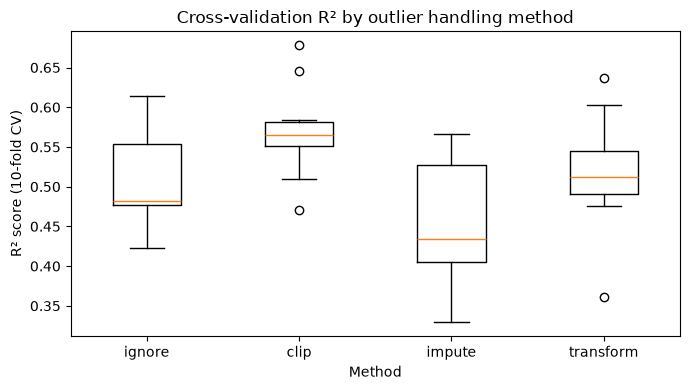


One-way ANOVA: F = 4.6755, p = 0.0074
At least one method produces significantly different R² scores (p < 0.05).


In [4]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.boxplot(cv_results.values(), tick_labels=list(cv_results.keys()))
ax.set_title('Cross-validation R² by outlier handling method')
ax.set_xlabel('Method')
ax.set_ylabel('R² score (10-fold CV)')
plt.tight_layout()
plt.show()

# One-way ANOVA across the four groups
f_stat, p_value = f_oneway(*cv_results.values())
print(f'\nOne-way ANOVA: F = {f_stat:.4f}, p = {p_value:.4f}')

if p_value < 0.05:
    print('At least one method produces significantly different R² scores (p < 0.05).')

else:
    print('No significant difference between methods detected (p ≥ 0.05).')

## 4. Threshold sensitivity experiment

The IQR factor controls how aggressively each method treats values as outliers. Below we sweep the threshold across values from 1.0 to 3.0 for both `clip` and `impute`, with `ignore` included once as a baseline control. A set of pair-wise t-tests with Holm-Bonferroni multiple testing correction to control family-wise error rate is used to asses statistical significance of differences.

### 4.1. Threshold evaluation

In [5]:
thresholds = [1.0, 1.25, 1.5, 1.75, 2.0, 2.25, 2.5, 2.75, 3.0]

configs = [('ignore', None, None)]

for t in thresholds:
    configs.append(('clip', t, None))

for t in thresholds:
    configs.append(('impute', t, 7))

cv_threshold_results = {}

for method, threshold, k in configs:

    df = housing_df.copy()
    feat_cols = [col for col in df.columns if col not in ('MedHouseVal', 'p_censored')]

    with contextlib.redirect_stdout(io.StringIO()):

        if method == 'clip':
            df = fl.clip_outliers(df, feat_cols, threshold=threshold)

        elif method == 'impute':
            df = fl.impute_outliers_with_knn(df, feat_cols, n_neighbors=k, threshold=threshold)

    label = 'ignore' if method == 'ignore' else f'{method} (t={threshold})'

    scores = cross_val_score(
        LinearRegression(),
        df.drop('MedHouseVal', axis=1),
        df['MedHouseVal'],
        cv=10,
        scoring='r2'
    )

    cv_threshold_results[label] = scores
    print(f'{label:>18}: mean R² = {scores.mean():.4f} ± {scores.std():.4f}')

            ignore: mean R² = 0.5110 ± 0.0593
      clip (t=1.0): mean R² = 0.5452 ± 0.0597
     clip (t=1.25): mean R² = 0.5595 ± 0.0578
      clip (t=1.5): mean R² = 0.5697 ± 0.0563
     clip (t=1.75): mean R² = 0.5761 ± 0.0551
      clip (t=2.0): mean R² = 0.5797 ± 0.0543
     clip (t=2.25): mean R² = 0.5811 ± 0.0536
      clip (t=2.5): mean R² = 0.5810 ± 0.0530
     clip (t=2.75): mean R² = 0.5802 ± 0.0524
      clip (t=3.0): mean R² = 0.5788 ± 0.0521
    impute (t=1.0): mean R² = 0.3415 ± 0.0893
   impute (t=1.25): mean R² = 0.4031 ± 0.0877
    impute (t=1.5): mean R² = 0.4526 ± 0.0771
   impute (t=1.75): mean R² = 0.4862 ± 0.0683
    impute (t=2.0): mean R² = 0.4990 ± 0.0665
   impute (t=2.25): mean R² = 0.5088 ± 0.0639
    impute (t=2.5): mean R² = 0.5198 ± 0.0648
   impute (t=2.75): mean R² = 0.5339 ± 0.0581
    impute (t=3.0): mean R² = 0.5429 ± 0.0561


### 4.2. Results

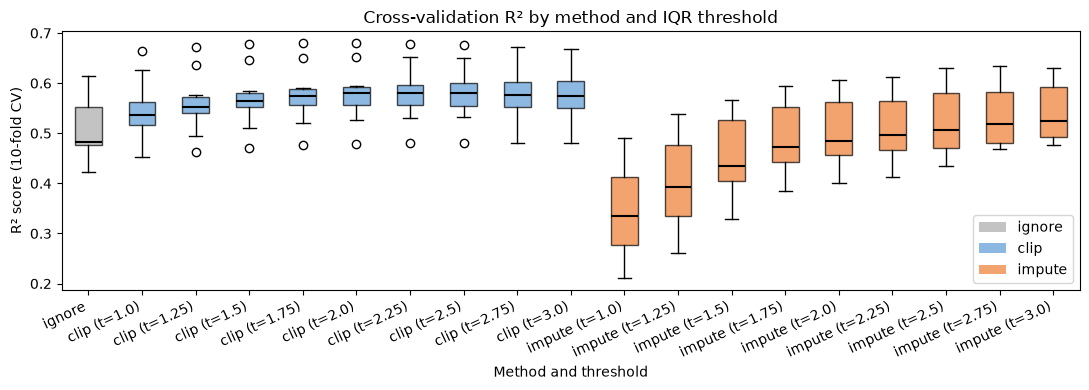


Paired t-tests vs ignore (Holm-Bonferroni; * = p_corr < 0.05):
  ignore vs       clip (t=1.0): t = -2.1300,  p_raw = 0.0620,  p_corr = 0.3101
  ignore vs      clip (t=1.25): t = -2.9946,  p_raw = 0.0151,  p_corr = 0.1056
  ignore vs       clip (t=1.5): t = -3.6392,  p_raw = 0.0054,  p_corr = 0.0487 *
  ignore vs      clip (t=1.75): t = -4.0735,  p_raw = 0.0028,  p_corr = 0.0306 *
  ignore vs       clip (t=2.0): t = -4.3589,  p_raw = 0.0018,  p_corr = 0.0219 *
  ignore vs      clip (t=2.25): t = -4.5400,  p_raw = 0.0014,  p_corr = 0.0183 *
  ignore vs       clip (t=2.5): t = -4.6401,  p_raw = 0.0012,  p_corr = 0.0174 *
  ignore vs      clip (t=2.75): t = -4.7031,  p_raw = 0.0011,  p_corr = 0.0174 *
  ignore vs       clip (t=3.0): t = -4.7210,  p_raw = 0.0011,  p_corr = 0.0174 *
  ignore vs     impute (t=1.0): t = +8.3949,  p_raw = 0.0000,  p_corr = 0.0003 *
  ignore vs    impute (t=1.25): t = +5.5866,  p_raw = 0.0003,  p_corr = 0.0058 *
  ignore vs     impute (t=1.5): t = +3.7705,  p_r

In [6]:
# Colour map: one colour per method group
def box_color(label):

    if label == 'ignore':        return '#aaaaaa'
    if label.startswith('clip'): return '#5b9bd5'
    return '#ed7d31'

labels = list(cv_threshold_results.keys())
colors = [box_color(l) for l in labels]

fig, ax = plt.subplots(figsize=(11, 4))

bp = ax.boxplot(
    cv_threshold_results.values(),
    tick_labels=labels,
    patch_artist=True
)

for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

for median in bp['medians']:
    median.set(color='black', linewidth=1.5)

ax.legend(handles=[
    Patch(facecolor='#aaaaaa', alpha=0.7, label='ignore'),
    Patch(facecolor='#5b9bd5', alpha=0.7, label='clip'),
    Patch(facecolor='#ed7d31', alpha=0.7, label='impute'),
], loc='lower right')

ax.set_title('Cross-validation R² by method and IQR threshold')
ax.set_xlabel('Method and threshold')
ax.set_ylabel('R² score (10-fold CV)')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()

ignore_scores = cv_threshold_results['ignore']
clip_scores   = [v for k, v in cv_threshold_results.items() if k.startswith('clip')]
impute_scores = [v for k, v in cv_threshold_results.items() if k.startswith('impute')]

# Collect paired t-test results across all 18 thresholds before correcting.
# We must gather all p-values first; multipletests needs the full family at once.
paired_keys = [k for k in cv_threshold_results if k != 'ignore']
t_stats, p_raws = [], []

for k in paired_keys:
    t_stat, p_raw = ttest_rel(ignore_scores, cv_threshold_results[k])
    t_stats.append(t_stat)
    p_raws.append(p_raw)

# Holm-Bonferroni controls family-wise error rate across all 18 comparisons.
# It is less conservative than Bonferroni because it adjusts each threshold
# stepwise, accounting for the tests already rejected.
reject, p_corrected, _, _ = multipletests(p_raws, alpha=0.05, method='holm')

print('\nPaired t-tests vs ignore (Holm-Bonferroni; * = p_corr < 0.05):')

for k, t_stat, p_raw, p_corr, rej in zip(paired_keys, t_stats, p_raws, p_corrected, reject):
    marker = ' *' if rej else ''
    print(f'  ignore vs {k:>18}: t = {t_stat:+.4f},  p_raw = {p_raw:.4f},  p_corr = {p_corr:.4f}{marker}')

In [7]:
# Collect paired t-test results across all 18 thresholds before correcting.
# We must gather all p-values first; multipletests needs the full family at once.
paired_keys = [k for k in cv_threshold_results if k != 'ignore']
t_stats, p_raws = [], []

for k in paired_keys:
    t_stat, p_raw = ttest_rel(ignore_scores, cv_threshold_results[k])
    t_stats.append(t_stat)
    p_raws.append(p_raw)

# Holm-Bonferroni controls family-wise error rate across all 18 comparisons.
# It is less conservative than Bonferroni because it adjusts each threshold
# stepwise, accounting for the tests already rejected.
reject, p_corrected, _, _ = multipletests(p_raws, alpha=0.05, method='holm')

print('\nPaired t-tests vs ignore (Holm-Bonferroni; * = p_corr < 0.05):')

for k, t_stat, p_raw, p_corr, rej in zip(paired_keys, t_stats, p_raws, p_corrected, reject):
    marker = ' *' if rej else ''
    print(f'  ignore vs {k:>18}: t = {t_stat:+.4f},  p_raw = {p_raw:.4f},  p_corr = {p_corr:.4f}{marker}')


Paired t-tests vs ignore (Holm-Bonferroni; * = p_corr < 0.05):
  ignore vs       clip (t=1.0): t = -2.1300,  p_raw = 0.0620,  p_corr = 0.3101
  ignore vs      clip (t=1.25): t = -2.9946,  p_raw = 0.0151,  p_corr = 0.1056
  ignore vs       clip (t=1.5): t = -3.6392,  p_raw = 0.0054,  p_corr = 0.0487 *
  ignore vs      clip (t=1.75): t = -4.0735,  p_raw = 0.0028,  p_corr = 0.0306 *
  ignore vs       clip (t=2.0): t = -4.3589,  p_raw = 0.0018,  p_corr = 0.0219 *
  ignore vs      clip (t=2.25): t = -4.5400,  p_raw = 0.0014,  p_corr = 0.0183 *
  ignore vs       clip (t=2.5): t = -4.6401,  p_raw = 0.0012,  p_corr = 0.0174 *
  ignore vs      clip (t=2.75): t = -4.7031,  p_raw = 0.0011,  p_corr = 0.0174 *
  ignore vs       clip (t=3.0): t = -4.7210,  p_raw = 0.0011,  p_corr = 0.0174 *
  ignore vs     impute (t=1.0): t = +8.3949,  p_raw = 0.0000,  p_corr = 0.0003 *
  ignore vs    impute (t=1.25): t = +5.5866,  p_raw = 0.0003,  p_corr = 0.0058 *
  ignore vs     impute (t=1.5): t = +3.7705,  p_r

## 5. Clean outliers

In [8]:
if OUTLIER_METHOD == 'clip':
    housing_df = fl.clip_outliers(housing_df, features, threshold=OUTLIER_THRESHOLD)

elif OUTLIER_METHOD == 'impute':
    housing_df = fl.impute_outliers_with_knn(
        housing_df, features, n_neighbors=7, threshold=OUTLIER_THRESHOLD
    )

elif OUTLIER_METHOD == 'transform':
    housing_df = fl.transform_outliers(housing_df, features)

else:
    print('Ignoring outliers; no changes made.')

MedInc: Outliers clipped to [-2.34, 9.65]
HouseAge: Outliers clipped to [-24.75, 79.75]
AveRooms: Outliers clipped to [0.81, 9.68]
AveBedrms: Outliers clipped to [0.80, 1.31]
Population: Outliers clipped to [-1323.50, 3835.50]
AveOccup: Outliers clipped to [0.51, 5.20]
Latitude: Outliers clipped to [25.42, 46.22]
Longitude: Outliers clipped to [-130.33, -109.48]


## 6. Cleaned feature distributions

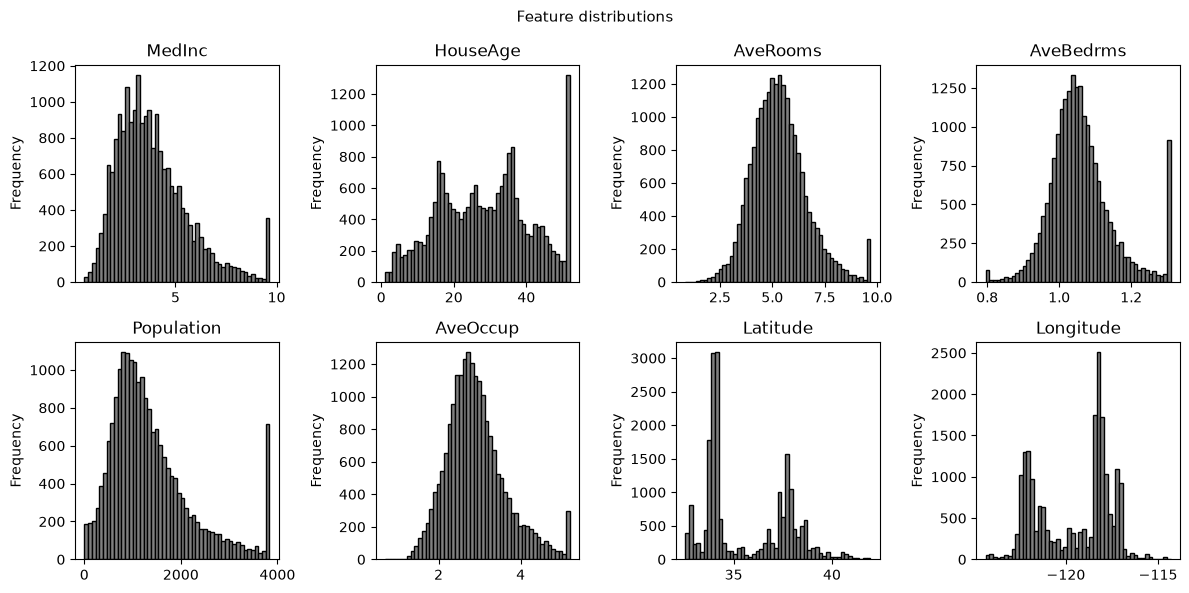

In [9]:
fl.plot_feature_distributions(housing_df)

## 7. Save output

In [10]:
out_path = DATA_DIR / '02-outlier-cleaning.csv'
housing_df.to_csv(out_path, index=False)
print(f'Saved: {out_path}')

Saved: /workspaces/featurely/data/02-outlier-cleaning.csv
